---
title: Multivariate > Conjoint Analysis
jupyter: python3
---

<div class="alert alert-info">Analyze responses from a conjoint survey to learn how much each product attribute level contributes to overall preference.</div>

## What conjoint analysis estimates

To set up a conjoint study from scratch we first determine the **attributes** and **attribute levels** that should be included. Once that has been done we would typically generate a *fractional factorial design* of conjoint profiles. This is a subset of all possible profiles that could be generated for the set of attributes and levels we selected (see *Design > DOE > Design of Experiments*). Presenting a respondent with every possible profile is usually infeasible, so a carefully chosen subset is used in which the attributes remain uncorrelated (orthogonal).

Once data is available from respondents, their evaluations are analyzed to determine **Part-Worths (PW)** and **Importance Weights (IW)**.

To estimate a model with `pyrsm` we pass the respondent's ratings (or rankings) as the response variable (`rvar`) and the profile attributes as the explanatory variables (`evar`). Under the hood, conjoint fits an ordinary least squares (OLS) regression of the evaluation on the attributes, where each attribute is treated as a categorical factor with its first level used as the base (treatment coding). The regression coefficients become the part-worths, and the part-worth ranges become the importance weights.

In [1]:
import polars as pl
import pyrsm as rsm

In [2]:
## setup pyrsm for autoreload
%reload_ext autoreload
%autoreload 2
%aimport pyrsm

## Example: MP3 player

The `mp3` dataset contains a respondent's ratings of MP3-player profiles described by five attributes. Each row is one product profile and the `Rating` column is the respondent's evaluation (higher = more preferred).

- **Memory** = storage capacity (4GB, 6GB, 8GB)
- **Radio** = built-in radio (No, Yes)
- **Size** = physical size (Large, Medium, Small)
- **Price** = price point ($50, $100, $150)
- **Shape** = device shape (Circular, Rectangular, Square)
- **Rating** = respondent's evaluation of the profile

In [3]:
mp3 = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/mp3.parquet"
)
mp3.head()

Rating,Memory,Radio,Size,Price,Shape
i32,enum,enum,enum,enum,enum
53,"""4GB""","""No""","""Small""","""$50""","""Square"""
65,"""6GB""","""Yes""","""Medium""","""$50""","""Square"""
50,"""4GB""","""Yes""","""Medium""","""$100""","""Square"""
68,"""8GB""","""No""","""Large""","""$100""","""Square"""
49,"""8GB""","""No""","""Small""","""$150""","""Square"""


## Estimate the conjoint model

Pass the data, the response variable, and the attributes. The `"Memory:Shape"` syntax selects the contiguous range of columns from `Memory` through `Shape` — all five attributes. Setting `mc_diag=True` adds the multicollinearity diagnostics described below.

In [4]:
cj = rsm.multivariate.conjoint({"mp3": mp3}, rvar="Rating", evar="Memory:Shape")
cj.summary(mc_diag=True)

Conjoint analysis
Data                 : mp3
Response variable    : Rating
Explanatory variables: Memory, Radio, Size, Price, Shape

Conjoint part-worths:
shape: (15, 3)
┌──────────────┬─────────────┬─────────┐
│ Attributes   ┆ Levels      ┆ PW      │
│ ---          ┆ ---         ┆ ---     │
│ str          ┆ str         ┆ f64     │
╞══════════════╪═════════════╪═════════╡
│ Memory       ┆ 4GB         ┆ 0.0     │
│ Memory       ┆ 6GB         ┆ 7.667   │
│ Memory       ┆ 8GB         ┆ 29.667  │
│ Radio        ┆ No          ┆ 0.0     │
│ Radio        ┆ Yes         ┆ 6.111   │
│ Size         ┆ Large       ┆ 0.0     │
│ Size         ┆ Medium      ┆ 6.333   │
│ Size         ┆ Small       ┆ 8.5     │
│ Price        ┆ $50         ┆ 0.0     │
│ Price        ┆ $100        ┆ -6.833  │
│ Price        ┆ $150        ┆ -33.833 │
│ Shape        ┆ Circular    ┆ 0.0     │
│ Shape        ┆ Rectangular ┆ -27.833 │
│ Shape        ┆ Square      ┆ -13.333 │
│ Base utility ┆ ~           ┆ 58.111  │
└─────────

### Orthogonality and the VIF diagnostics

The Variance Inflation Factor (VIF) measures how much the attributes are correlated with one another. In a well-designed fractional factorial study the profiles are deliberately selected so that all attributes are *orthogonal* (uncorrelated). When that holds, every VIF is close to 1 and the auxiliary `Rsq` values are close to 0, which tells us each attribute contributes independent information to the model. This is exactly what we want: it means the estimated part-worths for one attribute are not distorted by another.

## Reading the part-worths

**Part-worths** measure the utility (preference contribution) of each level *relative to that attribute's base level*. By construction the base level of every attribute is fixed at `0`, and the other levels are expressed as deviations from it. A positive part-worth means that level is preferred over the base level; a negative one means it is less preferred.

In [5]:
cj.PW

Attributes,Levels,PW
str,str,f64
"""Memory""","""4GB""",0.0
"""Memory""","""6GB""",7.667
"""Memory""","""8GB""",29.667
"""Radio""","""No""",0.0
"""Radio""","""Yes""",6.111
"""Size""","""Large""",0.0
"""Size""","""Medium""",6.333
"""Size""","""Small""",8.5
"""Price""","""$50""",0.0


The final row, `Base utility`, is the model **intercept**. It is the predicted evaluation when *every* attribute is set to its base level (here: 4GB, No radio, Large, $50, Circular). To predict the utility of any other profile, start from the base utility and add the part-worth of each chosen level.

For the MP3 data we can read off, for example, that moving from 4GB to 8GB adds a large positive utility, while moving from $50 to $150 subtracts a large amount — price and memory clearly matter a great deal to this respondent.

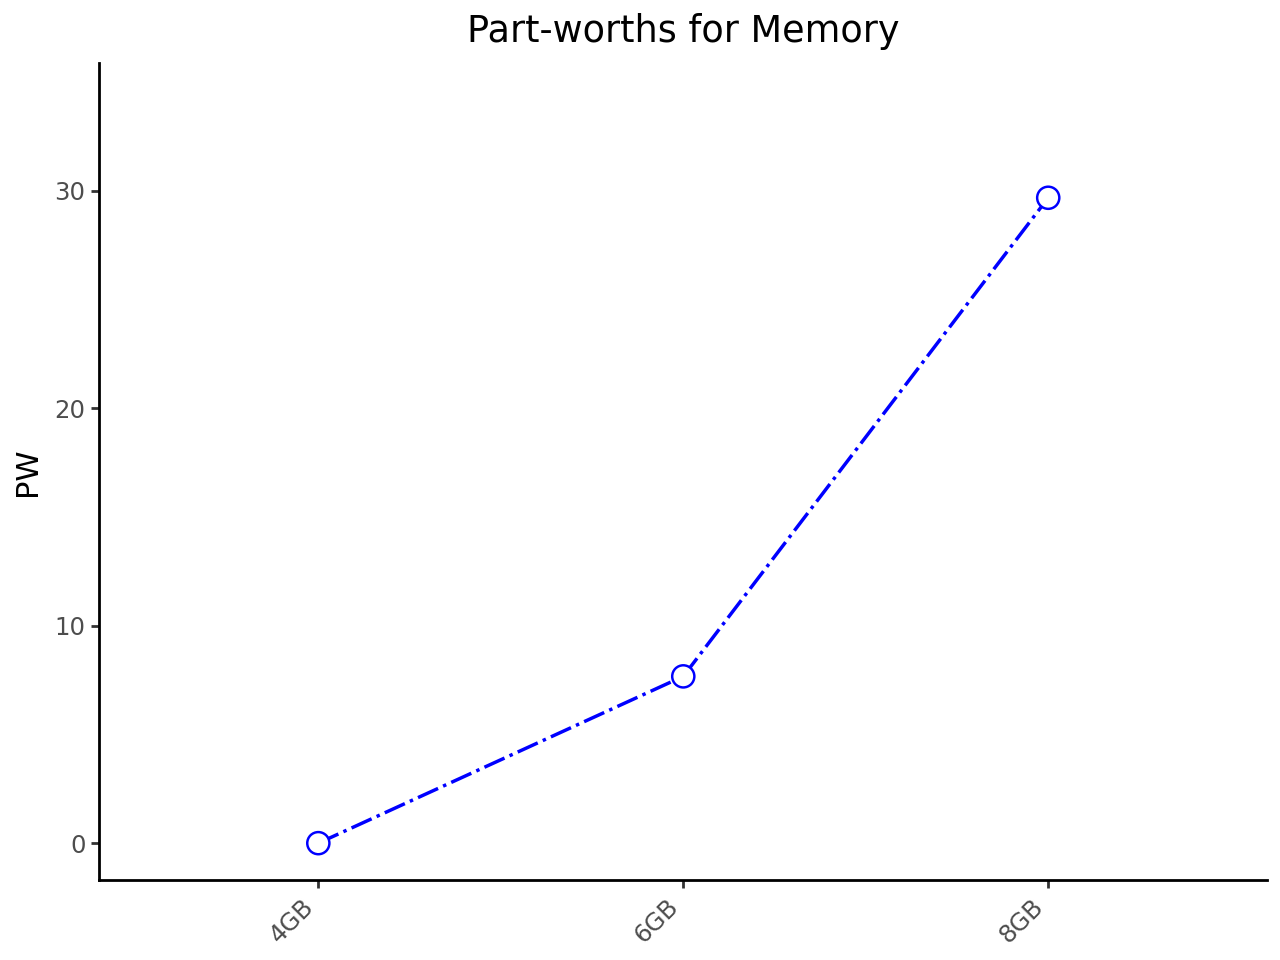

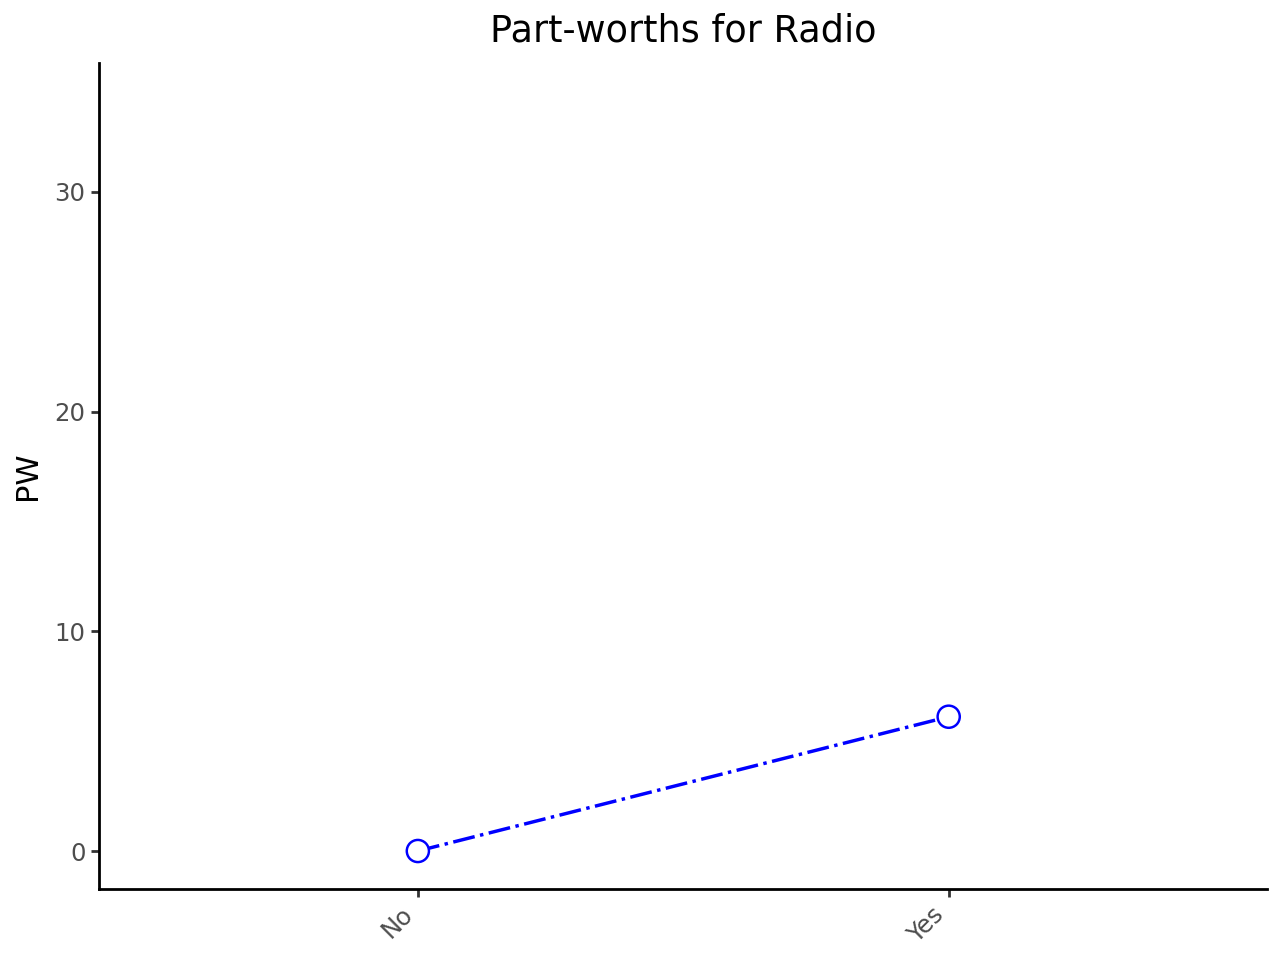

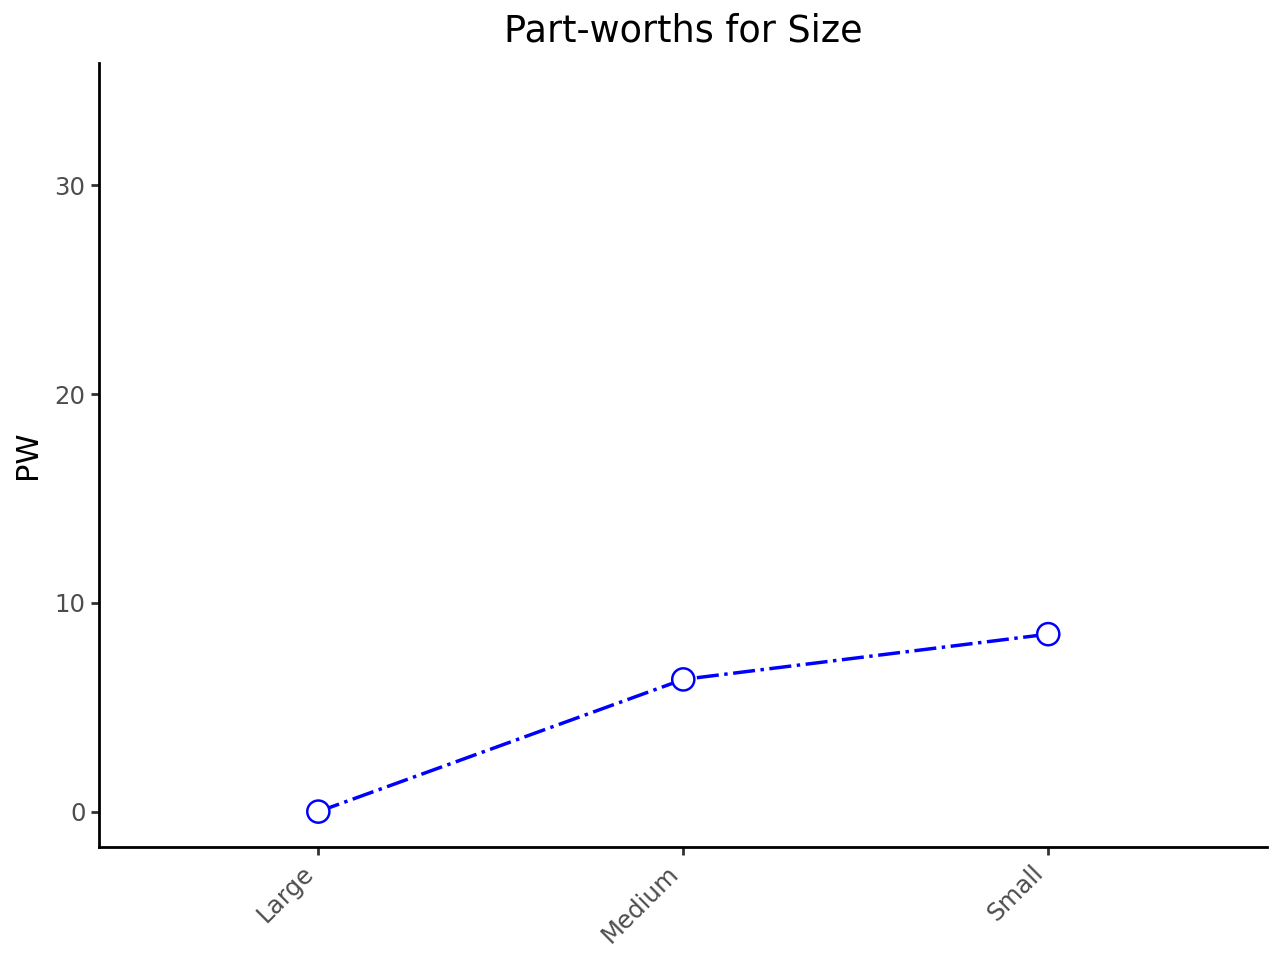

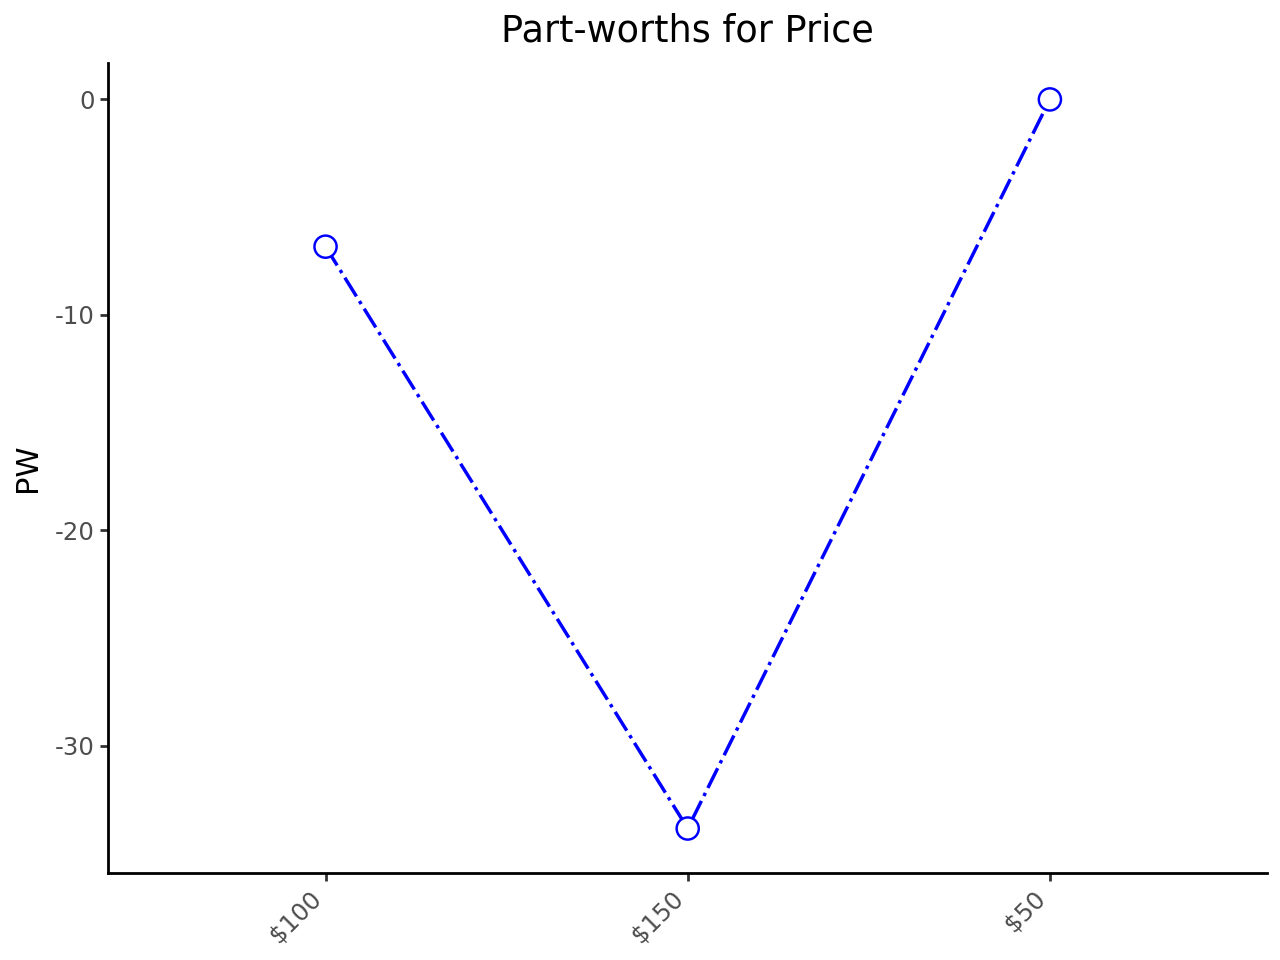

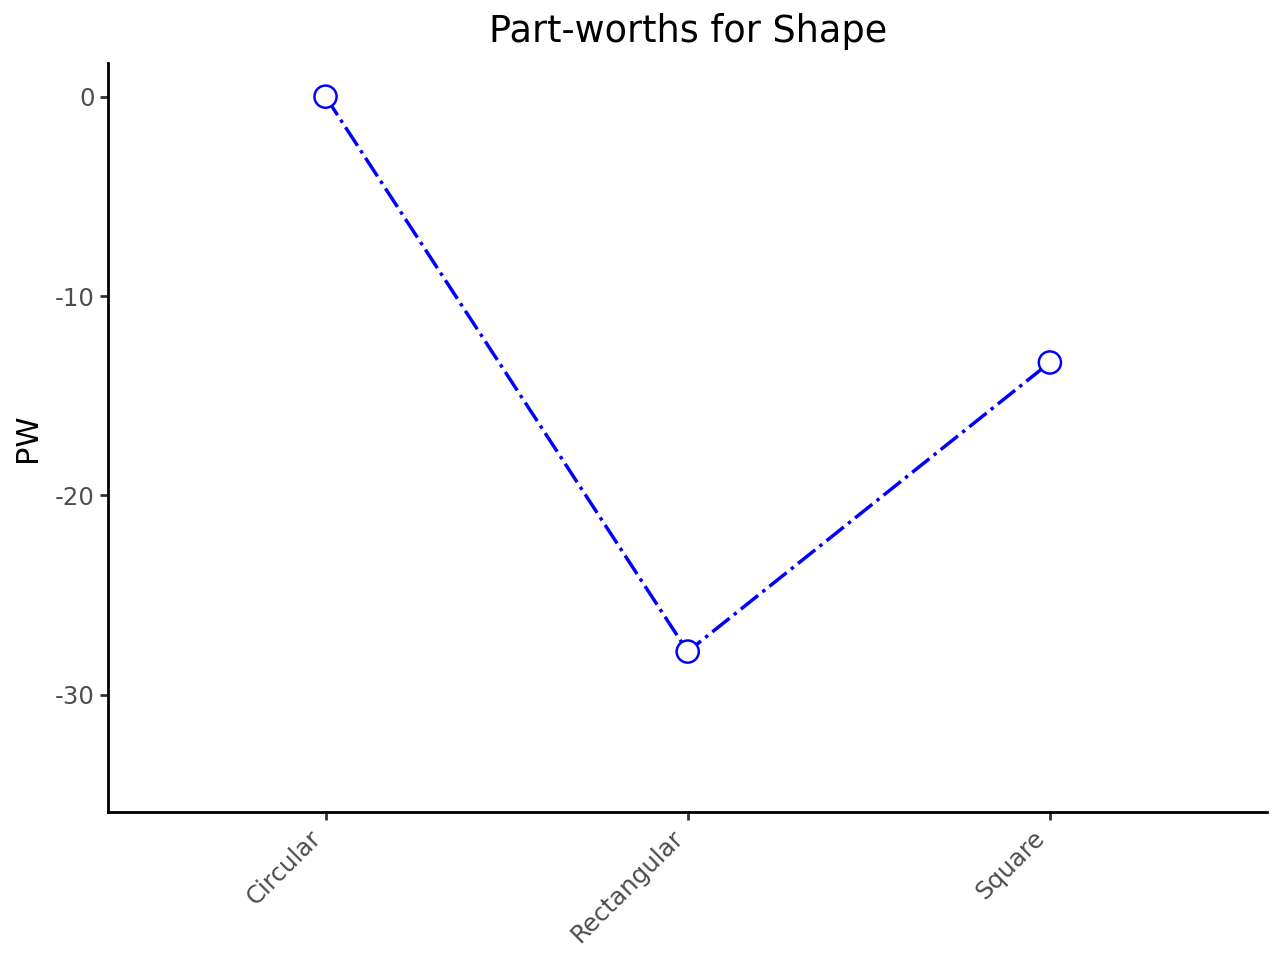

In [6]:
cj.plot(plots="pw", scale_plot=True)

The part-worth plots show one panel per attribute, with the levels on the x-axis and the part-worth utility on the y-axis. Using `scale_plot=True` puts every panel on a *shared* y-range so the attributes can be compared visually: a steep line spanning a wide range means that attribute strongly drives preference, while a nearly flat line means it barely matters.

## Reading the importance weights

**Importance weights** summarize how much each attribute drives preference overall. For each attribute we compute the *range* of its part-worths (highest minus lowest), then express that range as a fraction of the sum of all attribute ranges. The weights therefore sum to 1 (100%) and tell us the relative share of preference explained by each attribute.

In [7]:
cj.IW

Attributes,IW
str,f64
"""Memory""",0.28
"""Radio""",0.058
"""Size""",0.08
"""Price""",0.319
"""Shape""",0.263


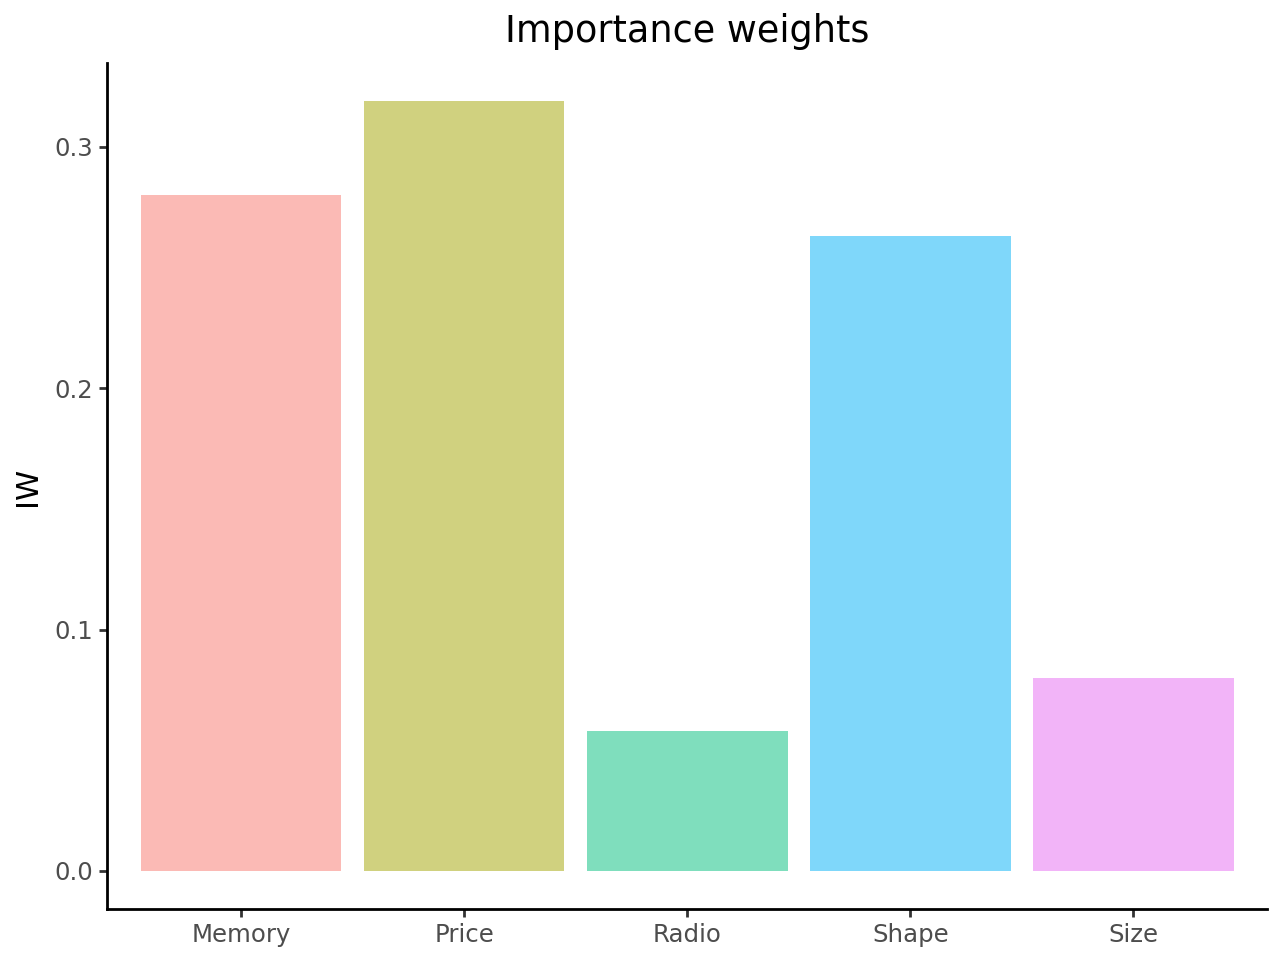

In [8]:
cj.plot(plots="iw")

Intuitively, an attribute is "important" if changing its level can swing the evaluation by a lot. For this respondent, Price and Memory have the largest weights, Shape is also substantial, and Radio and Size matter relatively little — useful guidance when deciding which features to prioritize in a product-design decision.

## The regression coefficients

The underlying OLS coefficients are available directly. The intercept maps to the base utility, and each `Attribute|Level` coefficient is the part-worth for that level. Standard errors, t-values, and p-values are included so you can judge which level differences are statistically reliable.

In [9]:
cj.coeff

label,coefficient,std.error,t.value,p.value
str,f64,f64,f64,f64
"""(Intercept)""",58.111111,0.891489,65.184309,3.4130e-12
"""Memory|6GB""",7.666667,0.690545,11.102348,0.000004
"""Memory|8GB""",29.666667,0.690545,42.96126,9.5025e-11
"""Radio|Yes""",6.111111,0.563827,10.838622,0.000005
"""Size|Medium""",6.333333,0.690545,9.171505,0.000016
"""Size|Small""",8.5,0.690545,12.309125,0.000002
"""Price|$100""",-6.833333,0.690545,-9.895571,0.000009
"""Price|$150""",-33.833333,0.690545,-48.995145,3.3327e-11
"""Shape|Rectangular""",-27.833333,0.690545,-40.306351,1.5796e-10


Conjoint stores a full model object per group in `cj.model_list` (keyed by `"full"` when no `by` grouping is used), which the prediction and plotting methods draw on.

In [10]:
list(cj.model_list.keys())

['full']

## Predicting profile utility

Use `predict` to score profiles. Calling it on the estimation data returns the fitted utility for each observed profile. The prediction equals the base utility plus the part-worths of the profile's levels.

In [11]:
cj.predict(mp3).head()

Prediction
f64
53.278
64.889
50.389
67.611
49.111


### Confidence vs. prediction intervals

Setting `se=True` adds interval bounds and a `+/-` margin of error around each prediction. There are two kinds of interval:

- A **confidence interval** (`interval="confidence"`) describes uncertainty about the *average* utility for a profile — how precisely we have estimated the mean evaluation. It is the narrower of the two.
- A **prediction interval** (`interval="prediction"`) describes uncertainty about a *single new evaluation* of that profile. It is wider because it adds the irreducible variability of an individual response on top of the estimation uncertainty.

In [12]:
cj.predict(mp3, se=True, interval="confidence").head()

Prediction,2.5%,97.5%,+/-
f64,f64,f64,f64
53.278,51.222,55.334,2.056
64.889,62.833,66.945,2.056
50.389,48.333,52.445,2.056
67.611,65.555,69.667,2.056
49.111,47.055,51.167,2.056


In [13]:
cj.predict(mp3, se=True, interval="prediction").head()

Prediction,2.5%,97.5%,+/-
f64,f64,f64,f64
53.278,49.838,56.718,3.44
64.889,61.449,68.329,3.44
50.389,46.949,53.829,3.44
67.611,64.171,71.051,3.44
49.111,45.671,52.551,3.44


### Storing predictions onto a dataset

`store_predictions` appends the prediction (and, when `se=True`, the lower/upper bounds and margin) back onto a dataset as new columns. Row counts must match, so predict on the same dataset you store into. This is handy for exporting scored profiles or for further analysis.

In [14]:
scored = rsm.multivariate.store_predictions(
    mp3, cj.predict(mp3, se=True), name="pred"
)
scored.head()

Rating,Memory,Radio,Size,Price,Shape,pred,pred_lb,pred_ub,pred_me
i32,enum,enum,enum,enum,enum,f64,f64,f64,f64
53,"""4GB""","""No""","""Small""","""$50""","""Square""",53.278,51.222,55.334,2.056
65,"""6GB""","""Yes""","""Medium""","""$50""","""Square""",64.889,62.833,66.945,2.056
50,"""4GB""","""Yes""","""Medium""","""$100""","""Square""",50.389,48.333,52.445,2.056
68,"""8GB""","""No""","""Large""","""$100""","""Square""",67.611,65.555,69.667,2.056
49,"""8GB""","""No""","""Small""","""$150""","""Square""",49.111,47.055,51.167,2.056


## Finding the optimal product via expand-grid

A key use of conjoint is to find the profile with the **highest predicted utility**, even profiles the respondent never actually saw. We can score *every* combination of selected levels using the `pred_cmd` argument, which expands the supplied levels into a full grid of profiles and predicts each one. Sorting by `Prediction` reveals the best (and worst) achievable products.

In [15]:
grid = cj.predict(pred_cmd={
    "Memory": ["4GB", "6GB", "8GB"],
    "Radio": ["Yes", "No"],
    "Size": ["Small", "Medium", "Large"],
    "Price": ["$50", "$100", "$150"],
    "Shape": ["Circular", "Rectangular", "Square"],
})
grid.sort("Prediction", descending=True).head()

Prediction
f64
102.389
100.222
96.278
95.556
94.111


The `pred_cmd` form returns only the `Prediction` column. To keep the attribute labels visible alongside each predicted utility, build the grid as a DataFrame and attach the predictions. The top row is the respondent's ideal product; the bottom row is the least preferred.

In [16]:
import itertools

mp3_levels = {
    "Memory": ["4GB", "6GB", "8GB"],
    "Radio": ["No", "Yes"],
    "Size": ["Large", "Medium", "Small"],
    "Price": ["$50", "$100", "$150"],
    "Shape": ["Circular", "Rectangular", "Square"],
}
rows = list(itertools.product(*mp3_levels.values()))
mp3_grid = pl.DataFrame(
    {k: [r[i] for r in rows] for i, k in enumerate(mp3_levels)}
)
mp3_scored = mp3_grid.with_columns(cj.predict(mp3_grid)["Prediction"])
mp3_scored.sort("Prediction", descending=True).head()

Memory,Radio,Size,Price,Shape,Prediction
str,str,str,str,str,f64
"""8GB""","""Yes""","""Small""","""$50""","""Circular""",102.389
"""8GB""","""Yes""","""Medium""","""$50""","""Circular""",100.222
"""8GB""","""No""","""Small""","""$50""","""Circular""",96.278
"""8GB""","""Yes""","""Small""","""$100""","""Circular""",95.556
"""8GB""","""No""","""Medium""","""$50""","""Circular""",94.111


## Reversed rankings: the carpet cleaner

Sometimes respondents provide a **ranking** rather than a rating. A respondent was presented with 18 product profiles for a carpet-cleaning product described on five attributes and asked to rank them from most preferred (rank 1) to least preferred (rank 18).

- **design** = Package Design (A, B, C)
- **brand** = Brand Name (K2R, Glory, Bissell)
- **price** = Price (1.19, 1.39, 1.59)
- **seal** = Good Housekeeping seal of approval (No, Yes)
- **money_back** = Money-Back Guarantee (No, Yes)
- **ranking** = respondent's ranking of the 18 profiles

Based on the attributes, 108 possible profiles could be created (3 x 3 x 3 x 2 x 2 = 108). The respondent saw a fractional factorial subset of 18 and ranked them. Because *lower* ranks mean *higher* preference, we set `reverse=True` so the response is flipped to `(max + 1) - rank`. After reversing, larger values once again mean higher preference and the part-worths read in the natural direction.

In [17]:
carpet = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/carpet.parquet"
)
cj_c = rsm.multivariate.conjoint(
    {"carpet": carpet}, rvar="ranking", evar="design:money_back", reverse=True
)
cj_c.summary(mc_diag=True)

Conjoint analysis
Data                 : carpet
Response variable    : ranking (reversed)
Explanatory variables: design, brand, price, seal, money_back

Conjoint part-worths:
shape: (14, 3)
┌──────────────┬─────────┬────────┐
│ Attributes   ┆ Levels  ┆ PW     │
│ ---          ┆ ---     ┆ ---    │
│ str          ┆ str     ┆ f64    │
╞══════════════╪═════════╪════════╡
│ design       ┆ A       ┆ 0.0    │
│ design       ┆ B       ┆ 8.0    │
│ design       ┆ C       ┆ 4.5    │
│ brand        ┆ K2R     ┆ 0.0    │
│ brand        ┆ Glory   ┆ -0.5   │
│ brand        ┆ Bissell ┆ 1.5    │
│ price        ┆ 1.19    ┆ 0.0    │
│ price        ┆ 1.39    ┆ -2.833 │
│ price        ┆ 1.59    ┆ -7.667 │
│ seal         ┆ No      ┆ 0.0    │
│ seal         ┆ Yes     ┆ 1.5    │
│ money_back   ┆ No      ┆ 0.0    │
│ money_back   ┆ Yes     ┆ 4.5    │
│ Base utility ┆ ~       ┆ 6.5    │
└──────────────┴─────────┴────────┘

Conjoint importance weights:
shape: (5, 2)
┌────────────┬───────┐
│ Attributes ┆ IW    │


The VIF diagnostics confirm the 18 profiles form a perfectly orthogonal design — every attribute is uncorrelated with the others, so the part-worths are cleanly identified.

In [18]:
cj_c.PW

Attributes,Levels,PW
str,str,f64
"""design""","""A""",0.0
"""design""","""B""",8.0
"""design""","""C""",4.5
"""brand""","""K2R""",0.0
"""brand""","""Glory""",-0.5
"""brand""","""Bissell""",1.5
"""price""","""1.19""",0.0
"""price""","""1.39""",-2.833
"""price""","""1.59""",-7.667


In [19]:
cj_c.IW

Attributes,IW
str,f64
"""design""",0.338
"""brand""",0.085
"""price""",0.324
"""seal""",0.063
"""money_back""",0.19


### Worked example: computing predicted utility by hand

With the part-worths above we can compute the utility of any profile by adding the base utility (`6.5`) to the part-worth of each chosen level. For example:

- **Package A, K2R, $1.19, no seal, no MBG**: `6.5 + 0 + 0 + 0 + 0 + 0 = 6.5`
- **Package C, Bissell, $1.19, no seal, with MBG**: `6.5 + 4.5 + 1.5 + 0 + 0 + 4.5 = 17`
- **Package B, Bissell, $1.59, with seal, with MBG**: `6.5 + 8.0 + 1.5 - 7.67 + 1.5 + 4.5 = 14.33`

### The highest-utility profile

What product maximizes this respondent's utility? Expand the full grid of 108 possible profiles, predict each one, and sort. The winner is **Package B, Bissell, $1.19, with seal, with MBG**, with a predicted utility of `22` — exactly what hand-computing the part-worths gives (`6.5 + 8.0 + 1.5 + 0 + 1.5 + 4.5 = 22`).

In [20]:
carpet_levels = {
    "design": ["A", "B", "C"],
    "brand": ["K2R", "Glory", "Bissell"],
    "price": ["1.19", "1.39", "1.59"],
    "seal": ["No", "Yes"],
    "money_back": ["No", "Yes"],
}
rows = list(itertools.product(*carpet_levels.values()))
carpet_grid = pl.DataFrame(
    {k: [r[i] for r in rows] for i, k in enumerate(carpet_levels)}
)
carpet_scored = carpet_grid.with_columns(cj_c.predict(carpet_grid)["Prediction"])
carpet_scored.sort("Prediction", descending=True).head()

design,brand,price,seal,money_back,Prediction
str,str,str,str,str,f64
"""B""","""Bissell""","""1.19""","""Yes""","""Yes""",22.0
"""B""","""K2R""","""1.19""","""Yes""","""Yes""",20.5
"""B""","""Bissell""","""1.19""","""No""","""Yes""",20.5
"""B""","""Glory""","""1.19""","""Yes""","""Yes""",20.0
"""B""","""Bissell""","""1.39""","""Yes""","""Yes""",19.167


## Interactions and by-group models

Two further options extend the basic model:

- **Interactions.** By default conjoint assumes the part-worths of one attribute do not depend on the levels of another (an additive model). To allow an interaction, pass `int="Memory:Shape"`, which adds product terms for those attributes and lets their joint effect differ from the sum of the individual part-worths.

- **By-group (multiple respondents).** If evaluations are available for several respondents and the dataset includes a respondent id, pass `by="respondent_id"` to fit a *separate* conjoint model for each respondent. Each respondent then has their own part-worths and importance weights (available per group in `cj.model_list`, and selectable via the `show=` argument on `summary`, `plot`, and `predict`). The individual-level part-worths or importance weights can be saved to a new dataset and used for **segmentation** (for example with K-means clustering) to find groups of customers who value the same features.

In [21]:
cj_int = rsm.multivariate.conjoint(
    {"mp3": mp3}, rvar="Rating", evar="Memory:Shape", int="Memory:Shape"
)
cj_int.coeff

label,coefficient,std.error,t.value,p.value
str,f64,f64,f64,f64
"""(Intercept)""",57.083333,1.972027,28.946533,0.000008
"""Memory|6GB""",8.666667,2.160247,4.011887,0.015972
"""Memory|8GB""",30.333333,1.870829,16.213849,0.000085
"""Radio|Yes""",6.666667,1.247219,5.345225,0.005905
"""Size|Medium""",6.25,1.080123,5.786376,0.004432
"""Size|Small""",8.75,1.080123,8.100926,0.001262
"""Price|$100""",-6.5,1.080123,-6.017831,0.003841
"""Price|$150""",-33.75,1.080123,-31.246428,0.000006
"""Shape|Rectangular""",-26.333333,2.160247,-12.189965,0.00026


## Discussion prompts

- Which attribute matters most to the MP3 respondent, and which matters least? How would the importance weights guide a product-design or pricing decision?
- Compare the confidence and prediction intervals for a profile. Why is one wider, and which would you report to a product manager who wants to know the *typical* rating a new buyer might give?
- For the carpet cleaner, verify by hand that the top profile from the expand-grid matches the sum of its part-worths. What is the *worst* possible product, and what does the gap between best and worst tell you about how much design choices matter to this respondent?